# 隔夜研究：净盈亏最差 vs 均值收益最低 — 相关性

**数据**：回测导出的 `text/overnight_pnl_by_symbol.csv`（按标的 `net_pnl_total`）与 `text/overnight_leg_symbol_return_rank.csv`（按标的 `mean_overnight_r` 等）。

- **净盈亏最差**：金额维度，大仓位 + 略负收益也可能排进「亏最多」。
- **均值收益最低**：比率维度，与 `overnight_symbol_mean_return_rank.png` 右侧 Bottom 一致时需同样过滤 `n_held`。

运行前请先完成一次回测（或把下面 `TEXT_DIR` 指到你的导出目录）。


In [6]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "scripts" / "qlib").is_dir():
        return here
    if (here.parent / "scripts" / "qlib").is_dir():
        return here.parent
    return here


REPO = find_repo_root()
# 可改为 os.environ["OVERNIGHT_TEXT_DIR"] 或绝对路径
TEXT_DIR = Path(os.environ.get("OVERNIGHT_TEXT_DIR", REPO / "qlib_runs" / "plots" / "text"))

PNL_CSV = TEXT_DIR / "overnight_pnl_by_symbol.csv"
RANK_CSV = TEXT_DIR / "overnight_leg_symbol_return_rank.csv"
MERGED_CSV = TEXT_DIR / "overnight_pnl_vs_mean_return_merge.csv"

TOP_N = 30  # 两榜单各取多少只做「最差 / 最低」集合对比
MIN_HELD = 3  # 与 overnight_symbol_mean_return_rank 图默认一致

print("仓库:", REPO)
print("text 目录:", TEXT_DIR)


仓库: /Users/yi/Projects/alpha-pipeline
text 目录: /Users/yi/Projects/alpha-pipeline/qlib_runs/plots/text


In [7]:
if MERGED_CSV.is_file():
    m = pd.read_csv(MERGED_CSV, encoding="utf-8")
    print(f"已读合并表: {MERGED_CSV.name}，行数 {len(m)}")
else:
    if not PNL_CSV.is_file():
        raise FileNotFoundError(f"缺少 {PNL_CSV}，请先回测导出或设置 OVERNIGHT_TEXT_DIR")
    if not RANK_CSV.is_file():
        raise FileNotFoundError(f"缺少 {RANK_CSV}")
    pnl = pd.read_csv(PNL_CSV, encoding="utf-8")
    rk = pd.read_csv(RANK_CSV, encoding="utf-8")
    m = pnl.merge(rk, on="symbol", how="inner", suffixes=("", "_rk"))
    if "n_held" in m.columns and MIN_HELD > 0:
        m = m[m["n_held"] >= MIN_HELD].copy()
    print(f"合并 pnl × rank，n_held≥{MIN_HELD} 后行数: {len(m)}")

for c in ("net_pnl_total", "mean_overnight_r"):
    if c in m.columns:
        m[c] = pd.to_numeric(m[c], errors="coerce")

m.head()

已读合并表: overnight_pnl_vs_mean_return_merge.csv，行数 372


,Unnamed: 0,symbol,n_overnight_legs,net_pnl_total,gross_loss_from_legs,gross_profit_from_legs,abs_cumulative_loss,rank_worst_net_pnl,rank_mean_return,rank_cumprod_return,...,n_overnight_down,down_minus_up,up_rate,down_rate,down_up_ratio,mean_when_up,mean_when_down,best_overnight,worst_overnight,n_flat
0,0,SZ300394,123,-50992.870605,-138053.871366,87061.000760,138053.871366,1,356,407,...,61,5,0.455285,0.495935,1.089286,0.012941,-0.017366,0.107786,-0.119225,6
1,1,SZ300251,21,-35912.258568,-44372.720032,8460.461465,44372.720032,2,406,405,...,14,7,0.333333,0.666667,2.000000,0.010542,-0.026051,0.021127,-0.149890,0
2,2,SZ300748,28,-29933.410521,-42078.608070,12145.197548,42078.608070,3,361,388,...,15,7,0.285714,0.535714,1.875000,0.004771,-0.007965,0.014973,-0.032852,5
3,3,SH600026,26,-21145.092634,-29374.826656,8229.734022,29374.826656,4,346,380,...,15,5,0.384615,0.576923,1.500000,0.010936,-0.011310,0.022599,-0.027848,1
4,4,SZ002371,76,-20344.744815,-48903.935097,28559.190282,48903.935097,5,304,397,...,51,29,0.289474,0.671053,2.318182,0.008910,-0.006125,0.032182,-0.016150,3


In [8]:
if m.empty:
    raise SystemExit("合并后无数据，检查 CSV 或降低 MIN_HELD")

pear = m["net_pnl_total"].corr(m["mean_overnight_r"])
spear = m["net_pnl_total"].corr(m["mean_overnight_r"], method="spearman")

pnl_only = m.sort_values("net_pnl_total", ascending=True)
mean_only = m.sort_values("mean_overnight_r", ascending=True)

set_worst_pnl = set(pnl_only.head(TOP_N)["symbol"].astype(str))
set_low_mean = set(mean_only.head(TOP_N)["symbol"].astype(str))
inter = set_worst_pnl & set_low_mean
union = set_worst_pnl | set_low_mean
jacc = len(inter) / len(union) if union else np.nan

summary = pd.DataFrame(
    {
        "指标": ["Pearson(net_pnl, mean_r)", "Spearman(net_pnl, mean_r)", "合并标的数", f"两榜各TOP_{TOP_N}交集数", "Jaccard(交集/并集)"],
        "值": [pear, spear, len(m), len(inter), jacc],
    }
)
summary

,指标,值
0,"Pearson(net_pnl, mean_r)",0.425365
1,"Spearman(net_pnl, mean_r)",0.715704
2,合并标的数,372.000000
3,两榜各TOP_30交集数,7.000000
4,Jaccard(交集/并集),0.132075


In [9]:
compare = pd.DataFrame({"symbol": sorted(union)})
compare["worst_net_pnl_top"] = compare["symbol"].isin(set_worst_pnl)
compare["lowest_mean_r_top"] = compare["symbol"].isin(set_low_mean)
compare["两榜重合"] = compare["symbol"].isin(inter)

meta = m.set_index("symbol")
compare["net_pnl_total"] = compare["symbol"].map(lambda s: meta.loc[s, "net_pnl_total"] if s in meta.index else np.nan)
compare["mean_overnight_r"] = compare["symbol"].map(
    lambda s: meta.loc[s, "mean_overnight_r"] if s in meta.index else np.nan
)
compare = compare.sort_values(["两榜重合", "net_pnl_total"], ascending=[False, True])
compare

,symbol,worst_net_pnl_top,lowest_mean_r_top,两榜重合,net_pnl_total,mean_overnight_r
46,SZ300251,True,True,True,-35912.258568,-0.013853
27,SZ000967,True,True,True,-16179.563582,-0.005028
17,SH688047,True,True,True,-14122.727114,-0.003831
8,SH600547,True,True,True,-11840.440394,-0.003778
28,SZ000975,True,True,True,-7723.729955,-0.004382
25,SZ000830,True,True,True,-7431.090274,-0.004553
19,SH688213,True,True,True,-6729.886384,-0.006902
47,SZ300394,True,False,False,-50992.870605,-0.002721
49,SZ300748,True,False,False,-29933.410521,-0.002904
0,SH600026,True,False,False,-21145.092634,-0.002319


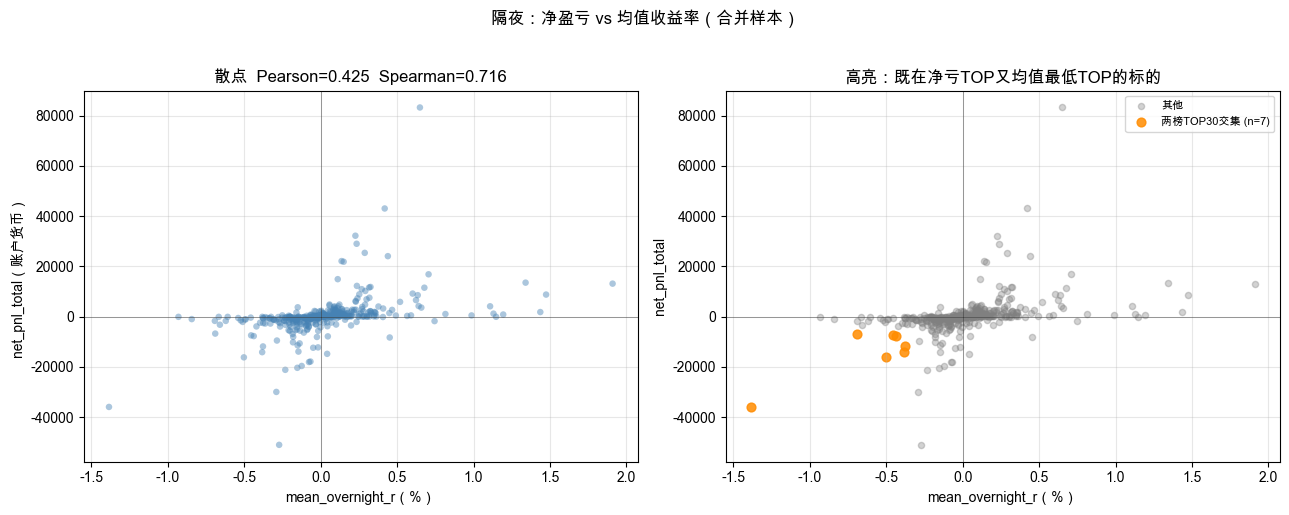

In [10]:
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = m["mean_overnight_r"].astype(float) * 100.0
y = m["net_pnl_total"].astype(float)
ax.scatter(x, y, s=22, alpha=0.45, c="steelblue", edgecolors="none")
ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.axvline(0, color="k", lw=0.5, alpha=0.5)
ax.set_xlabel("mean_overnight_r（%）")
ax.set_ylabel("net_pnl_total（账户货币）")
ax.set_title(f"散点  Pearson={pear:.3f}  Spearman={spear:.3f}")
ax.grid(True, alpha=0.3)

ax = axes[1]
in_both = m["symbol"].astype(str).isin(inter)
ax.scatter(
    m.loc[~in_both, "mean_overnight_r"].astype(float) * 100.0,
    m.loc[~in_both, "net_pnl_total"].astype(float),
    s=20,
    alpha=0.35,
    c="gray",
    label="其他",
)
ax.scatter(
    m.loc[in_both, "mean_overnight_r"].astype(float) * 100.0,
    m.loc[in_both, "net_pnl_total"].astype(float),
    s=40,
    alpha=0.85,
    c="darkorange",
    label=f"两榜TOP{TOP_N}交集 (n={in_both.sum()})",
)
ax.axhline(0, color="k", lw=0.5, alpha=0.5)
ax.axvline(0, color="k", lw=0.5, alpha=0.5)
ax.set_xlabel("mean_overnight_r（%）")
ax.set_ylabel("net_pnl_total")
ax.set_title("高亮：既在净亏TOP又均值最低TOP的标的")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("隔夜：净盈亏 vs 均值收益率（合并样本）", y=1.02)
fig.tight_layout()
plt.show()

## 说明

- **相关为正** 一般表示：均值隔夜越差（越负）的标的，累计净盈亏也越偏负（但仓位会放大金额，相关未必接近 1）。
- **Jaccard** 低但相关尚可：两榜单排序维度不同，集合不必高度重合。
- 可调 `TOP_N`、`MIN_HELD` 做敏感性对比（多跑几次或下面复制一格改参数）。
